<a href="https://colab.research.google.com/github/seonghoyu11/csci-473-files/blob/main/Lab3/Steve_Yoo_Fall2025_473_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weather Forecasting with Linear Regression
**Recitation by Dr. Fangshuo Liao**

In these lab sessions, we will be using Jupyter notebooks running on Google Colab, which has most Python libraries installed.

Please make a copy of the folder in your own Google Drive.

At the end of the recitation, we will be able to:

1.   Implement linear regression models using PyTorch and Pandas.
2.   Wrangle a real dataset.
3. Train a simple machine learning model.


## Weather prediction

In this recitation, we will implement a weather forecasting application with Python. We will use the weather recordings from New York City collected from [Open-Meteo](https://open-meteo.com/) between 2016 to 2022. You can find the data set in the column-separated file 'NYC_Weather_2016_2022.csv' in the Google Drive folder you had just copied and created.

We will start by allowing our application access to our local Google drives so files can be loaded into our Python programs.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


On the left-side menu in your Google Colab, find the Files symbol to access your Google Drive contents. Under _content/drive/MyDrive_ you will see all of your files and folders. Find the local copy to the the data set _NYC_Weather_2016_2022.csv_ and copy the path by clicking on it on the right three-dot symbol and selecting **_Copy path_**. Inset the path in the read_csv function as string input.

A common library useful for data processing applications in Python is **pandas**. We will use the csv file reader method to load our file contents from the column-separated file into a **DataFrame**, a class type defined to store and handle operations with two-dimensional tabular data.

In [9]:
import pandas as pd
import os
data_folder = os.getcwd() + '/drive/MyDrive/' # Your path here

print(os.listdir(data_folder))
df = pd.read_csv(data_folder + 'NYC_Weather_2016_2022.csv')
df.head(10)

['Copy of Blank Schedule 2023.docx', 'Registration Checklist Summer 2024.gdoc', 'Tutoring Request Form FA21.pdf', 'Untitled document (12).gdoc', 'Untitled document (11).gdoc', 'Steve Yoo_Resume 2024.pdf', 'Accidental Hero.gdoc', 'Conway Text.gdoc', 'Untitled document (10).gdoc', 'Steve Yoo - Math Modeling Research.gdoc', 'Steve Yoo - Math Modeling Research.pdf', 'Copy of CS1114 PTC Mock Exam1 Fall 2024.docx', '시니어 컨설팅   멘토링 마켓 조사.gdoc', 'comp sci midterm exam 1 notes.gdoc', '10 24 Frontend 8.5-8.7.gslides', '시니어즈 시장 조사 script.gdoc', 'Copy of 멋사 와이어프레임.gslides', 'Copy of cs questions 1.gdoc', '제목 없는 스프레드시트.gsheet', 'Steve Yoo_Resume 2024 (1).docx', 'Lab.gdoc', 'Chem Slides', 'Cham.pdf', 'Chem.pdf', '2조 예상 질문 리스트.gdoc', 'Untitled document (9).gdoc', 'Untitled document (8).gdoc', 'Symbols and Abbreviations.xlsx', 'EG Notes.gdoc', ' Four-Trophic-Level Food Web Model .gdraw', 'lab1b - james, kaylyn, steve.rvt', 'Steve Yoo -Lab 1 

,time,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
0,2016-01-01T00:00,7.6,0.0,0.0,69.0,53.0,0.0,72.0,10.0,296.0
1,2016-01-01T01:00,7.5,0.0,0.0,20.0,4.0,0.0,56.0,9.8,287.0
2,2016-01-01T02:00,7.1,0.0,0.0,32.0,3.0,0.0,99.0,9.7,285.0
3,2016-01-01T03:00,6.6,0.0,0.0,35.0,5.0,0.0,100.0,9.2,281.0
4,2016-01-01T04:00,6.3,0.0,0.0,34.0,4.0,0.0,100.0,9.1,279.0
5,2016-01-01T05:00,6.1,0.0,0.0,35.0,5.0,0.0,100.0,9.4,277.0
6,2016-01-01T06:00,6.0,0.0,0.0,50.0,21.0,1.0,100.0,9.7,274.0
7,2016-01-01T07:00,5.9,0.0,0.0,51.0,24.0,0.0,98.0,9.7,272.0
8,2016-01-01T08:00,5.8,0.0,0.0,54.0,26.0,1.0,99.0,9.0,265.0
9,2016-01-01T09:00,5.8,0.0,0.0,58.0,31.0,1.0,99.0,10.2,262.0


The description of the attributes of the [DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) class can be seen in the documentation. When we print the first 10 lines of the data stored in the **df** object that represents our csv file we see that it has 10 columns. The first column identifies each individual weather measurement using a timestamp recording the time of the measurement.

The rest of the 9 columns store different types of weather information that could be relevant to any meteorological analysis. Note that different sources might be recording different types and amount of measurements depending on the availability of measurement tools or the relevance to the specific application.

We could also use the built-in function _describe()_ to obtain an initial statistical summary of the data set, which will compute and display the count, mean, standard deviation, and minimum/maximum values for each of the columns, or the measurement types, in the DataFrame.

In [10]:
df.describe()

,temperature_2m (°C),precipitation (mm),rain (mm),cloudcover (%),cloudcover_low (%),cloudcover_mid (%),cloudcover_high (%),windspeed_10m (km/h),winddirection_10m (°)
count,59592.000000,59592.000000,59592.000000,59592.000000,59592.000000,59592.000000,59592.000000,59592.000000,59587.000000
mean,13.247721,0.133713,0.123401,45.448131,25.605702,30.109746,40.287203,11.379841,203.724420
std,9.804465,0.542782,0.525858,38.265304,37.161502,36.839594,42.526615,5.802103,99.719142
min,-18.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,5.200000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,7.200000,129.000000
50%,13.500000,0.000000,0.000000,35.000000,2.000000,10.000000,20.000000,10.400000,222.000000
75%,21.800000,0.000000,0.000000,89.000000,46.000000,58.000000,92.000000,14.500000,288.000000
max,35.500000,19.200000,19.200000,100.000000,100.000000,100.000000,100.000000,47.200000,360.000000


We can access the contents of each measurement using the **iloc** attribute which has indexing functionality.

For instance, we could extract the first ten temperature measurements as follows:

In [11]:
df.iloc[0:10, 1]

,temperature_2m (°C)
0,7.6
1,7.5
2,7.1
3,6.6
4,6.3
5,6.1
6,6.0
7,5.9
8,5.8
9,5.8


# Let's inspect visually how the individual measurements from New York City weather are distributed through the six years of collection.

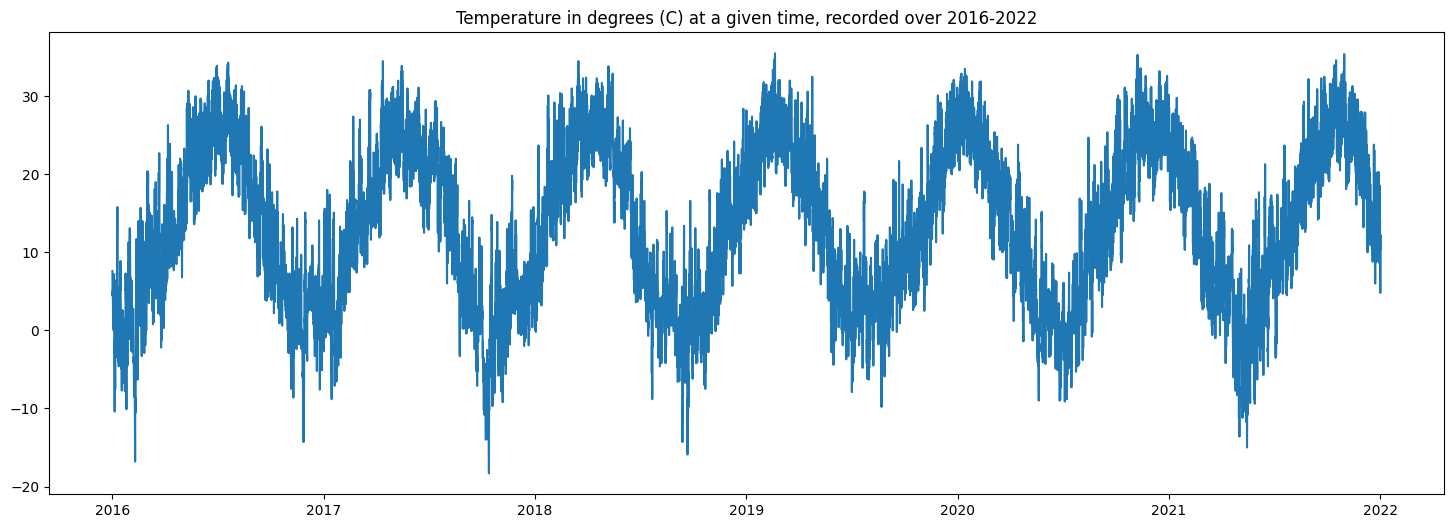

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 6))

df['temperature_2m (°C)'].plot()
plt.title('Temperature in degrees (C) at a given time, recorded over 2016-2022')
plt.xticks([59592/6*i for i in range(7)], ['2016', '2017', '2018', '2019', '2020', '2021', '2022'])
plt.show()

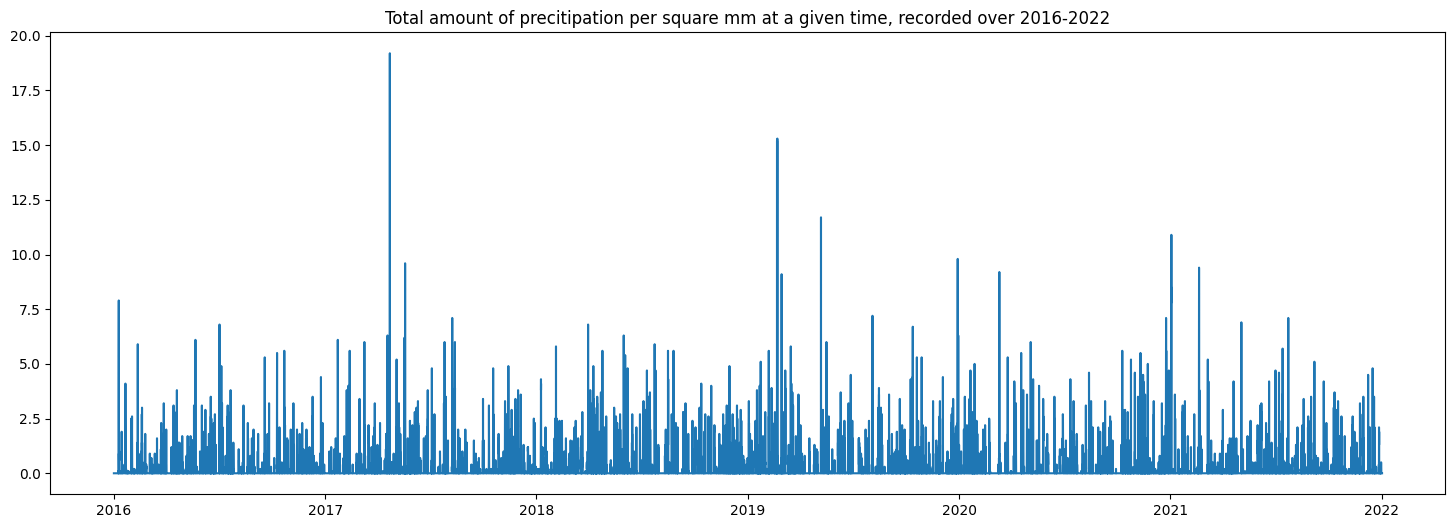

In [13]:
plt.figure(figsize=(18, 6))

df['precipitation (mm)'].plot()
plt.title('Total amount of precitipation per square mm at a given time, recorded over 2016-2022')
plt.xticks([59592/6*i for i in range(7)], ['2016', '2017', '2018', '2019', '2020', '2021', '2022'])
plt.show()

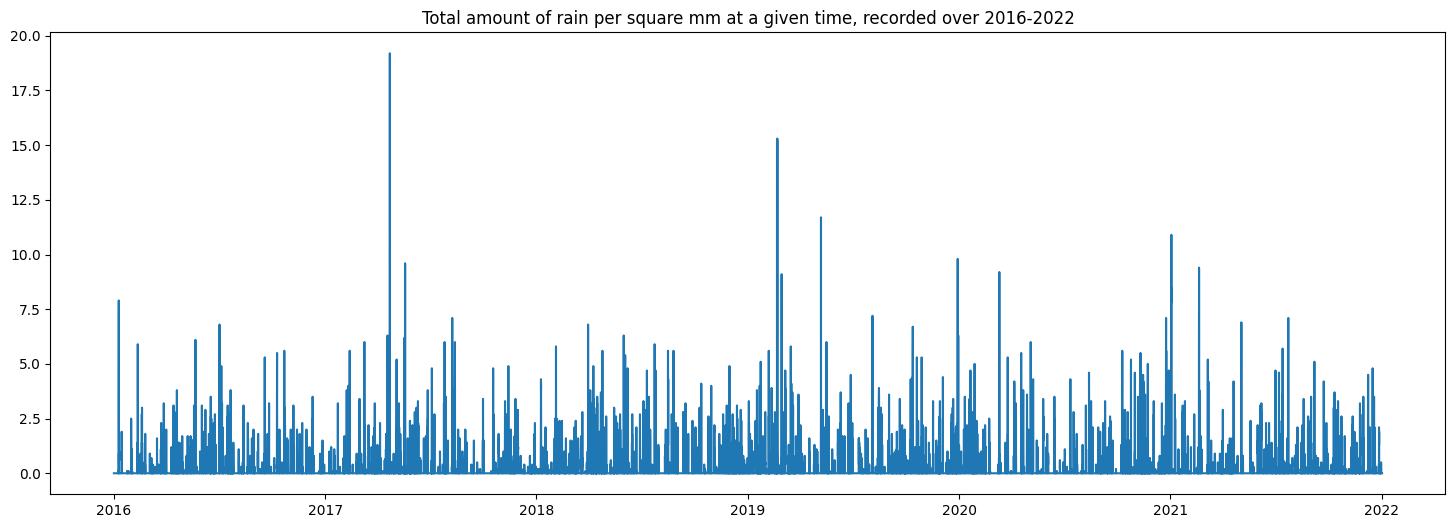

In [14]:
plt.figure(figsize=(18, 6))

df['rain (mm)'].plot()
plt.title('Total amount of rain per square mm at a given time, recorded over 2016-2022')
plt.xticks([59592/6*i for i in range(7)], ['2016', '2017', '2018', '2019', '2020', '2021', '2022'])
plt.show()

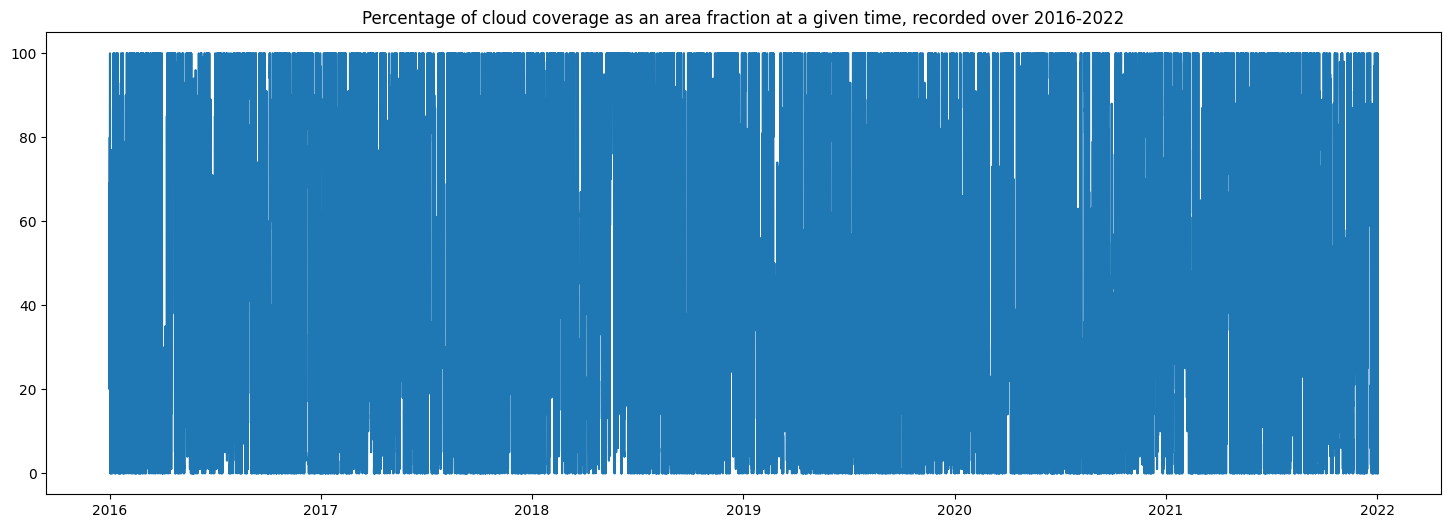

In [15]:
plt.figure(figsize=(18, 6))

df['cloudcover (%)'].plot()
plt.title('Percentage of cloud coverage as an area fraction at a given time, recorded over 2016-2022')
plt.xticks([59592/6*i for i in range(7)], ['2016', '2017', '2018', '2019', '2020', '2021', '2022'])
plt.show()

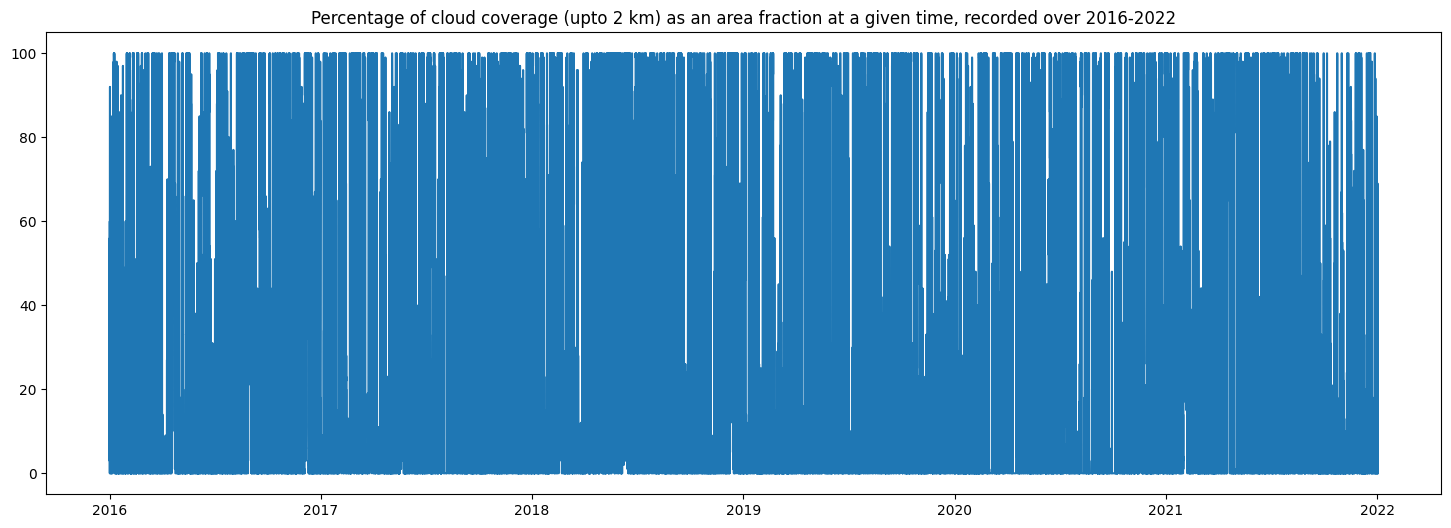

In [16]:
plt.figure(figsize=(18, 6))

df['cloudcover_low (%)'].plot()
plt.title('Percentage of cloud coverage (upto 2 km) as an area fraction at a given time, recorded over 2016-2022')
plt.xticks([59592/6*i for i in range(7)], ['2016', '2017', '2018', '2019', '2020', '2021', '2022'])
plt.show()

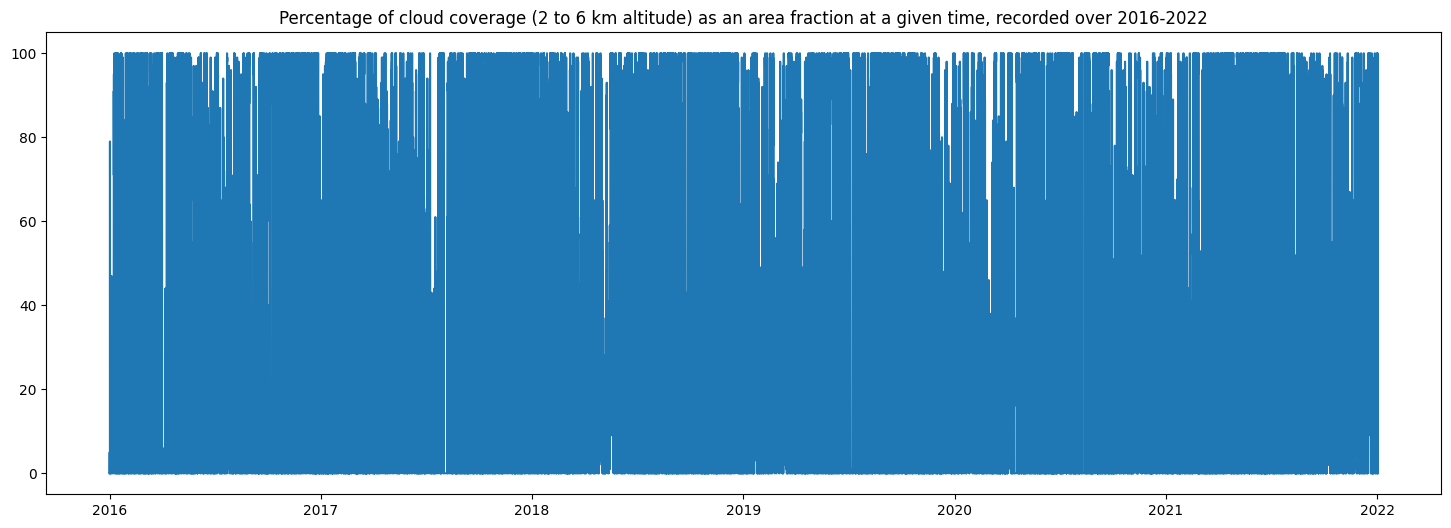

In [17]:
plt.figure(figsize=(18, 6))

df['cloudcover_mid (%)'].plot()
plt.title('Percentage of cloud coverage (2 to 6 km altitude) as an area fraction at a given time, recorded over 2016-2022')
plt.xticks([59592/6*i for i in range(7)], ['2016', '2017', '2018', '2019', '2020', '2021', '2022'])
plt.show()

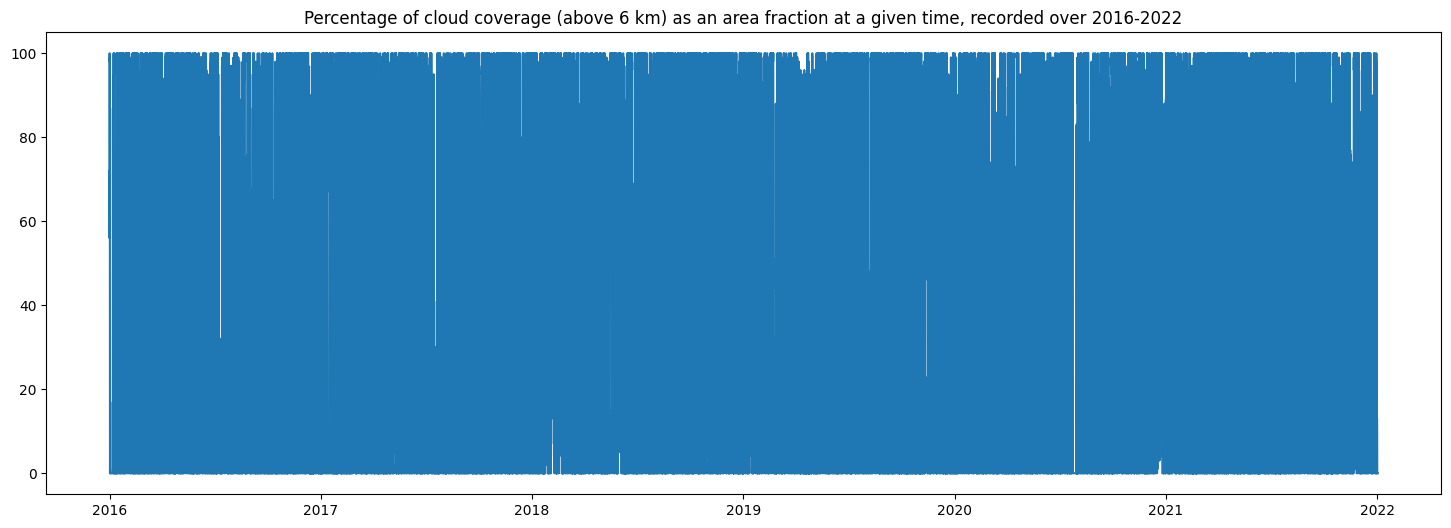

In [18]:
plt.figure(figsize=(18, 6))

df['cloudcover_high (%)'].plot()
plt.title('Percentage of cloud coverage (above 6 km) as an area fraction at a given time, recorded over 2016-2022')
plt.xticks([59592/6*i for i in range(7)], ['2016', '2017', '2018', '2019', '2020', '2021', '2022'])
plt.show()

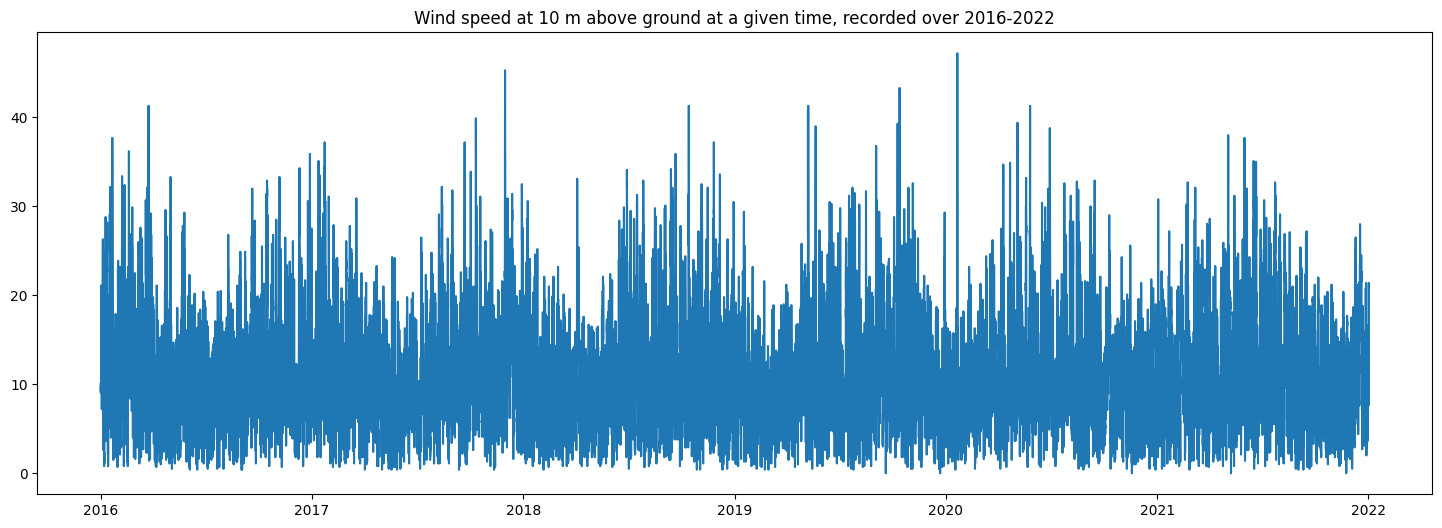

In [19]:
plt.figure(figsize=(18, 6))

df['windspeed_10m (km/h)'].plot()
plt.title('Wind speed at 10 m above ground at a given time, recorded over 2016-2022')
plt.xticks([59592/6*i for i in range(7)], ['2016', '2017', '2018', '2019', '2020', '2021', '2022'])
plt.show()

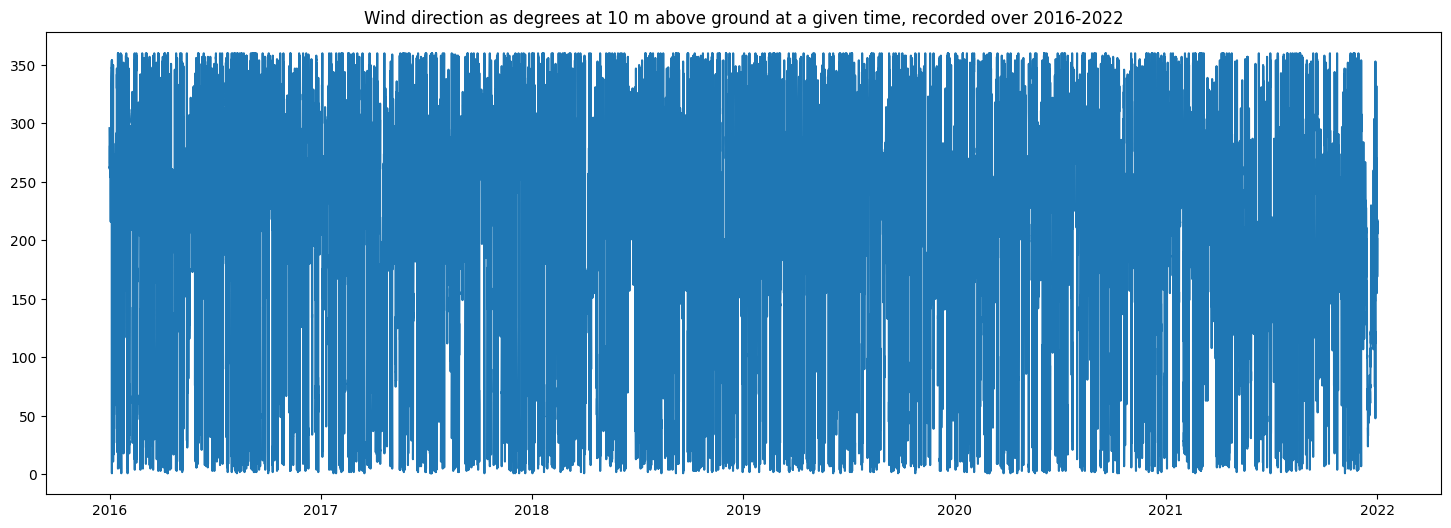

In [20]:
plt.figure(figsize=(18, 6))

df['winddirection_10m (°)'].plot()
plt.title('Wind direction as degrees at 10 m above ground at a given time, recorded over 2016-2022')
plt.xticks([59592/6*i for i in range(7)], ['2016', '2017', '2018', '2019', '2020', '2021', '2022'])
plt.show()

## Rain prediction with linear regression

If we wanted to try to make predictions on the probability of observing rain at a given day and time, we could use these measurement data to build a prediction model. Here, any of the remaining measurements could be used to see if they could be potential indicators of observing rain.

Let's see how each individual meteorological feature has a relationship with the rain data.

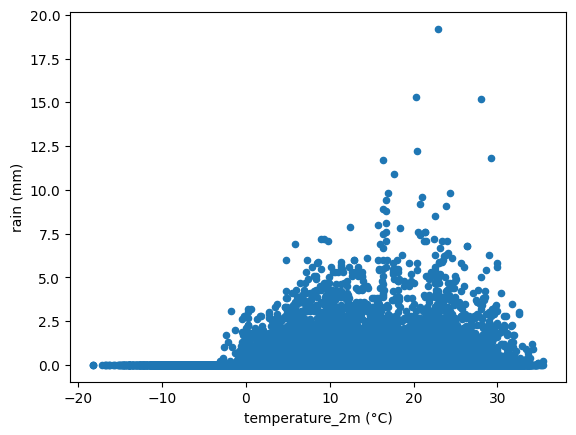

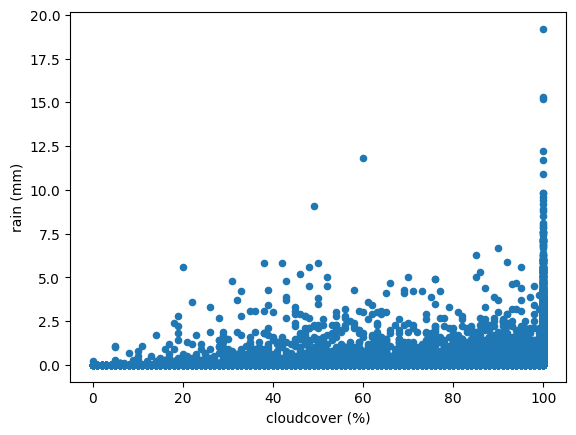

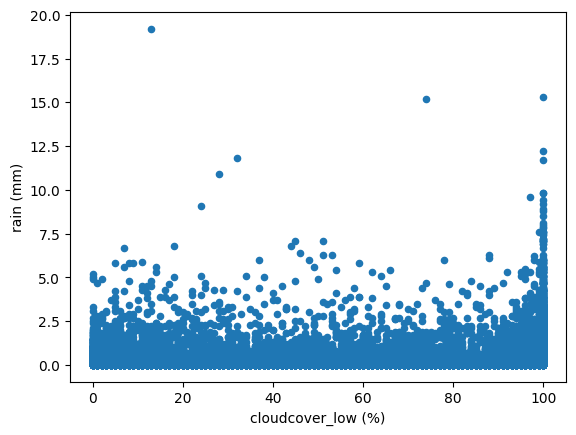

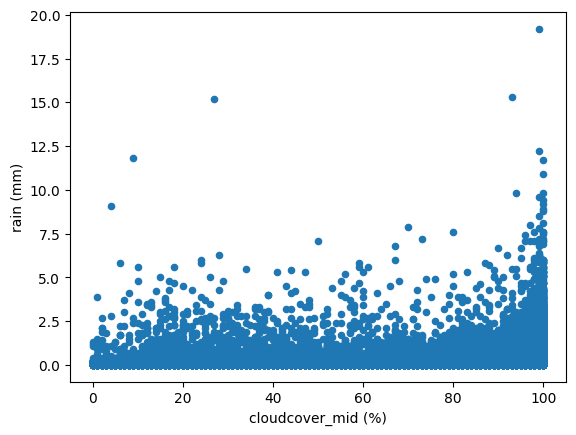

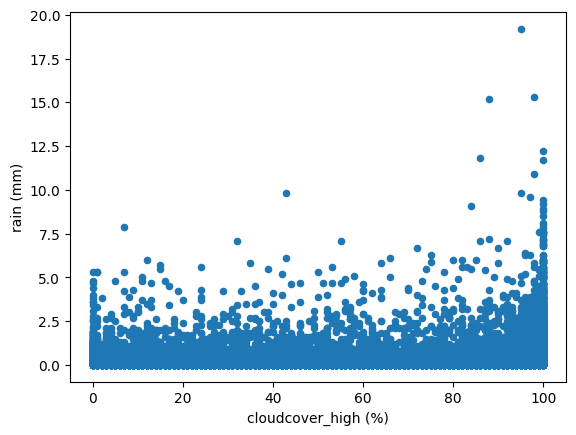

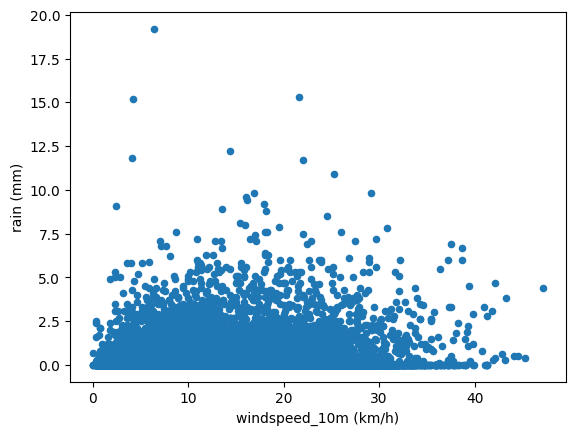

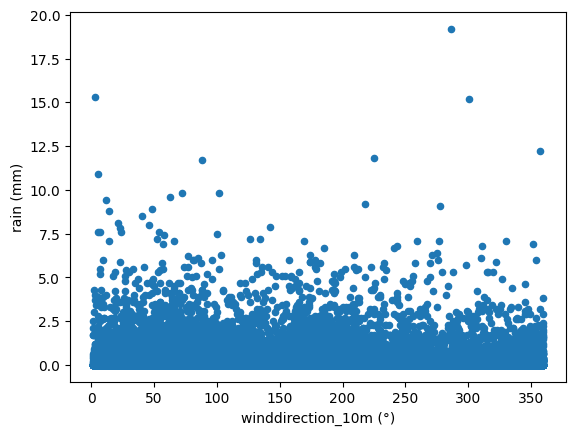

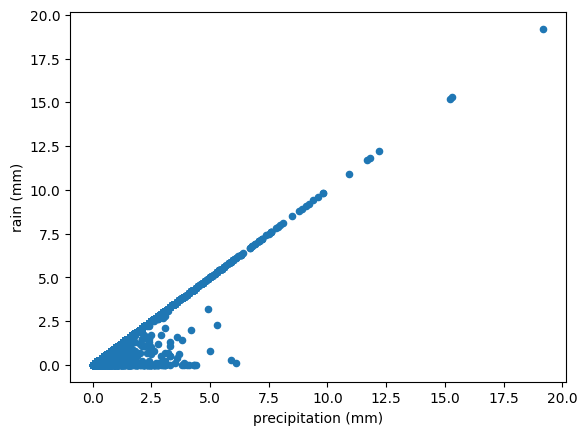

In [21]:
import matplotlib.pyplot as plt

axs1 = df.plot.scatter(x='temperature_2m (°C)', y='rain (mm)')
axs2 = df.plot.scatter(x='cloudcover (%)', y='rain (mm)')
axs3 = df.plot.scatter(x='cloudcover_low (%)', y='rain (mm)')
axs4 = df.plot.scatter(x='cloudcover_mid (%)', y='rain (mm)')
axs5 = df.plot.scatter(x='cloudcover_high (%)', y='rain (mm)')
axs6 = df.plot.scatter(x='windspeed_10m (km/h)', y='rain (mm)')
axs7 = df.plot.scatter(x='winddirection_10m (°)', y='rain (mm)')
axs8 = df.plot.scatter(x='precipitation (mm)', y='rain (mm)')

The development of any machine learning model requires a basis to evaluate the accuracy of the model performance. In order to assess whether the built model is useful for the target application, we always divide parts of our data set into separate parts: **training** set contains the examples the model will learn from, and during training the ongoing improvement in accuracy can be validated in the **validation** set. The final predictions must always be conducted on a separate **testing** set, which will present unseen examples to the model to make predictions on such that we can evaluate how well the model has learnt to use its knowledge to generalize into varying new information in realistic application scenarios.

We start manipulating our data set by cleaning and filtering operations to ensure each learning example is as clean and representative as possible. In order to create representative examples from different dates and times, we randomly sample portions from our data set to form training and testing sets.

In [22]:
import torch

df = df.dropna() # first filter out any empty rows and columns in the dataset
datatensor = torch.tensor(df.values[1:,1::].astype(float)) # We can remove the first row and column since it contains non-numeric data

# apply normalization techniques
datatensor = torch.nn.functional.normalize(datatensor)
print(datatensor)

# randomly select 80% of the examples and store in the training set for teaching the model
# remaining 20% will be used for evaluating the predictions
train, test = torch.utils.data.random_split(datatensor, [0.8, 0.2])
traindata = torch.stack([t for t in train])
testdata = torch.stack([t for t in test])

tensor([[0.0256, 0.0000, 0.0000,  ..., 0.1909, 0.0334, 0.9782],
        [0.0234, 0.0000, 0.0000,  ..., 0.3260, 0.0319, 0.9386],
        [0.0220, 0.0000, 0.0000,  ..., 0.3327, 0.0306, 0.9349],
        ...,
        [0.0531, 0.0000, 0.0000,  ..., 0.0000, 0.0723, 0.9013],
        [0.0537, 0.0000, 0.0000,  ..., 0.0000, 0.0522, 0.9966],
        [0.0478, 0.0000, 0.0000,  ..., 0.0000, 0.0354, 0.9982]],
       dtype=torch.float64)


## Defining the Model

Let's start our program by defining the linear regression model. We will use the [Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) layer implementation in PyTorch which will automatically create a module containing model parameters. By setting bias=False, the model we define is

$$
  f(\mathbf{w},\mathbf{x}) = \mathbf{w}^\top\mathbf{x} = \sum_{j=1}^dw_ix_i
$$

If we set bias=True, then the model is

$$
  f_{bias}(\mathbf{w},\mathbf{x}) = w_0 + \mathbf{w}^\top\mathbf{x} = w_0 + \sum_{j=1}^dw_ix_i
$$

In [23]:
import torch

class LinearRegression(torch.nn.Module):
    def __init__(self, inputSize, outputSize):
        super(LinearRegression, self).__init__()
        # a default Linear projection layer with weights A and bias B s.t. x_{out} = x_{in}^\top w + b
        self.linear = torch.nn.Linear(inputSize, outputSize, bias=False)

    def forward(self, x):
        y = self.linear(x)
        return y

## Defining the Loss
Next, we will define how the model will be trained on the selected prediction task. Our model will use the training data to learn from. In order to measure how model outputs compare to the target (or correct) predictions we need to define a distance metric that computes the differences between the predicted and correct rain values. We can use the mean squared error function to define our loss function:

$$
  L(\mathbf{w}) = \frac{1}{n}\sum_{i=1}^n(f(\mathbf{w}, \mathbf{x}_i) - y_i)^2 = \frac{1}{n}\|\mathbf{X}\mathbf{w} - \mathbf{y}||_2^2
$$

In [24]:
loss = torch.nn.MSELoss()

The data we will use to represent the learning examples, i.e. training set, will contain all 9 measurements that could aid the prediction objective, or the regression task. The prediction measurement, rain values, will be the target data and will represent the correct output. Here, we use the sampled training collection of rain data as target examples of correct prediction, and use the remaining as test set to evaluate model performance.


In [25]:
# We can create separate tensors to input and output to the model
train_in = torch.cat([traindata[:,0:2], traindata[:,3::]], dim=1) # everything but rain
test_in = torch.cat([testdata[:,0:2], testdata[:,3::]], dim=1)    # rain

train_out = traindata[:,2].unsqueeze(1)
test_out = testdata[:,2].unsqueeze(1)

# Check if the final data includes any of the rain measurements
print(train_in[1,:])
print(test_in[1,:])

print(traindata.shape)
print(testdata.shape)
print(traindata[1,:])
print(testdata[1,:])

print(train_in.shape)
print(test_in.shape)
print(train_out.shape)
print(test_out.shape)

tensor([0.0286, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0732, 0.9969],
       dtype=torch.float64)
tensor([0.0028, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0855, 0.9963],
       dtype=torch.float64)
torch.Size([47669, 9])
torch.Size([11917, 9])
tensor([0.0286, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0732, 0.9969],
       dtype=torch.float64)
tensor([0.0028, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0855, 0.9963],
       dtype=torch.float64)
torch.Size([47669, 8])
torch.Size([11917, 8])
torch.Size([47669, 1])
torch.Size([11917, 1])


## Feature Standardization

Before we proceed into the training, we need to make sure that the distribution of each feature to be mean 0 and std 1. This will speed up training **a lot**

In [26]:
train_in_mean = train_in.mean(axis=0)
train_out_mean = train_out.mean()

train_in_std = train_in.std(axis=0)
train_out_std = train_out.std()

print('==========Mean and Std before Processing==========')
print(train_in_mean, train_out_std)

ptrain_in = (train_in - train_in_mean) / train_in_std
ptrain_out = (train_out - train_out_mean) / train_out_std

print('==========Mean and Std after Processing==========')
print(ptrain_in.mean(axis=0), ptrain_in.std(axis=0))

==========Mean and Std before Processing==========
tensor([7.0813e-02, 5.9460e-04, 2.1296e-01, 1.1971e-01, 1.3701e-01, 1.9008e-01,
        5.8655e-02, 8.0873e-01], dtype=torch.float64) tensor(0.0024, dtype=torch.float64)
==========Mean and Std after Processing==========
tensor([-2.5042e-17, -1.9079e-17,  4.6208e-18,  1.4906e-18, -8.4814e-17,
        -9.2416e-17, -4.5612e-17,  2.8619e-17], dtype=torch.float64) tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       dtype=torch.float64)




A typical machine learning training cycle is implemented with **batch** processing, which passes multiple inputs and receives multiple outputs simultaneously to the model. The size of the batch, represented at batch time, will determine the intervals at which gradient accumulation will be computed. Each time, **batch size** examples are used together to evaluate a joint gradient, and afterwards the model parameters are updated after the outputs of all examples in the batch are generated.

PyTorch allows automatic batch creation through the Dataset class. Here we will modify the base class to implement our own data set representation.

In [27]:
from torch.utils.data import Dataset, DataLoader

class WeatherDataset(Dataset):
  def __init__(self, inputs, outputs):
        # Initialize data
        self.n_samples = inputs.shape[0]

        # here the first column is the class label, the rest are the features
        self.x_data = inputs # size [n_samples, n_features]
        self.y_data = outputs # size [n_samples, 1]

  # support indexing such that dataset[i] can be used to get i-th sample
  def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

  # we can call len(dataset) to return the size
  def __len__(self):
      return self.n_samples


trainingData = WeatherDataset(ptrain_in, ptrain_out)

We can now implement the model training and testing in our program. We will define our model with its size parameters for the input and output, and create an iterative loop for optimizing the model parameters using gradient descent:

$$
  \mathbf{w}_{t+1} = \mathbf{w}_t - \eta \nabla L(\mathbf{w}_t)
$$

Another important parameter is the **learning rate** $\eta$ which determines the scale at which each parameter update will be performed by the optimizer. We run the training for 50 steps.

In [28]:
def train(learning_rate, batch_size, num_epochs):
  model = LinearRegression(inputSize=8, outputSize=1)
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

  loader = DataLoader(dataset=trainingData, batch_size=batch_size, shuffle=False)

  losses = []; step = 0

  for epoch_idx in range(num_epochs):
    for input, target in loader:
      optimizer.zero_grad() # reset gradiant value to zero
      model.double()
      output = model(input) # pass input to model
      err = loss(output, target) # compute mean squared error between model prediction and target value
      losses.append(err) # store err value to monitor training
      # evaluate the gradient at the end of the computational graph

      err.backward()

      # propagate the evaluated gradient to update model parameters
      optimizer.step()

      print('step {}, loss {}'.format(step, err.item()))

      step += 1
  return model, losses

learning_rate = 0.1
batch_size = len(trainingData)
num_epochs = 50


print('Total Iters: ', len(trainingData) // batch_size * num_epochs)
print('Output Scale: ', torch.norm(ptrain_out) ** 2 / len(trainingData))
model, losses = train(learning_rate, batch_size, num_epochs)

Total Iters:  50
Output Scale:  tensor(1.0000, dtype=torch.float64)
step 0, loss 1.2632900594331498
step 1, loss 0.7736619470560361
step 2, loss 0.5613306613911606
step 3, loss 0.42377426019050196
step 4, loss 0.32712070690514117
step 5, loss 0.25813447257968963
step 6, loss 0.2085866360378895
step 7, loss 0.1728155605552429
step 8, loss 0.14685357375631242
step 9, loss 0.1279040826679808
step 10, loss 0.11398818125814932
step 11, loss 0.1037004491354415
step 12, loss 0.09603912428151613
step 13, loss 0.0902875393441273
step 14, loss 0.08593106691781906
step 15, loss 0.08259875060814391
step 16, loss 0.08002215351222489
step 17, loss 0.07800625229664537
step 18, loss 0.07640878399541481
step 19, loss 0.0751255421334156
step 20, loss 0.07407987291518132
step 21, loss 0.07321514573598648
step 22, loss 0.07248933668582008
step 23, loss 0.07187111805067914
step 24, loss 0.07133702478767598
step 25, loss 0.07086939381815785
step 26, loss 0.07045485983001015
step 27, loss 0.07008325325581154

Text(0, 0.5, 'Loss')

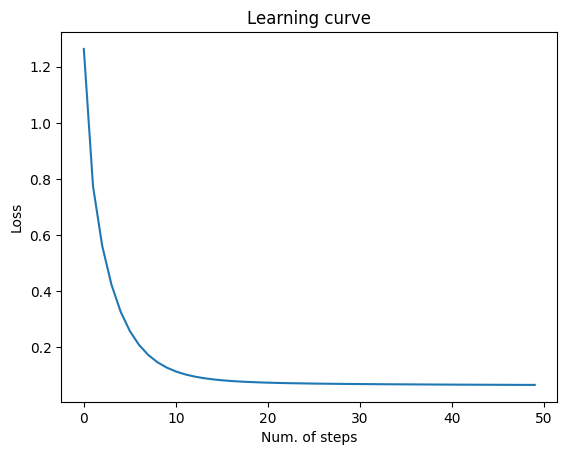

In [31]:
import matplotlib.pyplot as plt

plt.plot(range(len(losses)), torch.stack(losses).detach())
plt.title('Learning curve')
plt.xlabel('Num. of steps')
plt.ylabel('Loss')

When the loss minimization is complete, we can now use the learned model parameters for the actual prediction task. We will use the testing features as input to the model and compare the model output with the actual rain measurements.

Text(0.5, 1.0, 'Linear regression model performance in New York City rain prediction')

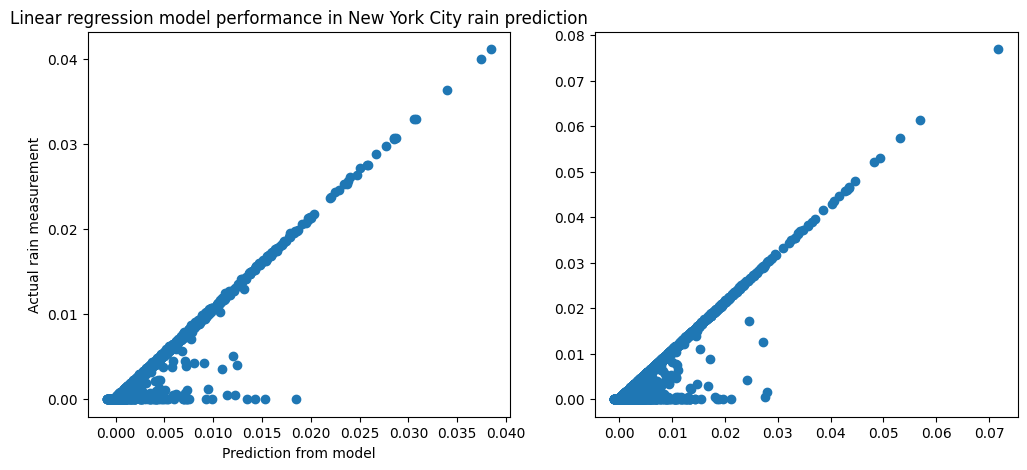

In [29]:
with torch.no_grad(): # this signal informs torch that further operations will not need the gradient computation
  ## Remember to process the input for the test!!!

  ptest_in = (test_in - train_in_mean) / train_in_std
  raw_test_pred = model(ptest_in)
  raw_train_pred = model(ptrain_in)

  ## Remember to scale the outputs back!!!
  test_pred = raw_test_pred * train_out_std + train_out_mean
  train_pred = raw_train_pred * train_out_std + train_out_mean

plt.figure(figsize=(12, 5))

ax1 = plt.subplot(121)
ax1.scatter(test_pred, test_out)

ax2 = plt.subplot(122)
ax2.scatter(train_pred, train_out)

ax1.set_xlabel('Prediction from model')
ax1.set_ylabel('Actual rain measurement')
ax1.set_title('Linear regression model performance in New York City rain prediction')

## Check the feature influence

In [30]:
for param in model.parameters():
  print(param.data)

tensor([[ 0.0285,  0.9634, -0.1292,  0.0638,  0.0261,  0.0184, -0.0333, -0.0396]],
       dtype=torch.float64)


## Exercise 1

Let $\mathbf{X} \in\mathbb{R}^{n\times d}$ be the training input and $\mathbf{y}\in\mathbb{R}^{n}$ be the output. Linear regression has the closed form solution

$$
  \mathbf{w}^\star = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}
$$

Implement the closed form solution based on the input ptrain_in and output ptrain_out, and compare it with the GD solution by computing the $\ell_2$-norm. Plot the training data and test data prediction v.s. true values in the scatter plot based on $\mathbf{w}^\star$.

GD Param: tensor([ 0.0285,  0.9634, -0.1292,  0.0638,  0.0261,  0.0184, -0.0333, -0.0396],
       dtype=torch.float64)
W^* = tensor([ 2.7391e-02,  9.7580e-01,  2.9283e-02, -7.7650e-04, -1.7333e-02,
         4.8716e-03, -1.3188e-02,  3.6498e-02], dtype=torch.float64)
L2 Norm: 0.19419495514385363


Text(0, 0.5, 'Actual rain measurement')

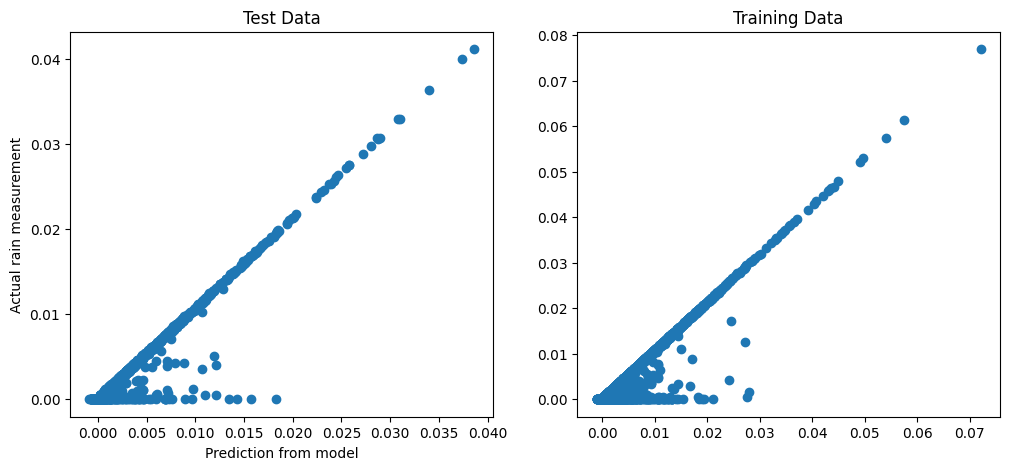

In [39]:
# Retrieve the GD parameter
GD_w = None
for param in model.parameters():
  if param.data.shape[1] == 8:
    GD_w = param.data.reshape((-1,))
    break

print('GD Param:', GD_w)

X = ptrain_in
y = ptrain_out.reshape((-1,))
y_unscaled = train_out

X_test = (test_in - train_in_mean) / train_in_std
y_test_unscaled = test_out


## Your code here.
w_star = torch.linalg.inv(X.T @ X) @ X.T @ y
print(f"W^* = {w_star}")

## Compute and print out the \ell_2 norm difference. (Remember to flatten your w_star!)
l_2_norm = torch.norm(w_star - GD_w)
print(f"L2 Norm: {l_2_norm}")

## Plot predictions v.s. true labels. Remember to scale things correctly!
train_pred_scaled = X @ w_star
test_pred_scaled = X_test @ w_star

train_pred = train_pred_scaled * train_out_std + train_out_mean
test_pred = test_pred_scaled * train_out_std + train_out_mean

plt.figure(figsize=(12, 5))

ax1 = plt.subplot(121)
ax1.scatter(test_pred, test_out)
ax1.set_title("Test Data")

ax2 = plt.subplot(122)
ax2.scatter(train_pred, train_out)
ax2.set_title("Training Data")

ax1.set_xlabel('Prediction from model')
ax1.set_ylabel('Actual rain measurement')

## Exercise 2

In the GD example above, we are using a learning rate of 0.1. Now, run the same training for 10 epochs with different choices of learning rate $\{0.28, 0.21, 0.14, 0.07\}$. For each learning rate, plot the convergence curve. Moreover, plot the curve of final loss v.s. learning rate.

Number of Axes Available:  5
step 0, loss 1.8815483391133025
step 1, loss 0.8551228331991767
step 2, loss 0.5565461674966449
step 3, loss 0.44056329534145783
step 4, loss 0.37692532732729933
step 5, loss 0.33153888770420553
step 6, loss 0.29484977459279105
step 7, loss 0.2637875450770765
step 8, loss 0.2370750476699814
step 9, loss 0.21398189555209013
step 0, loss 1.557423633247749
step 1, loss 0.5663582435299513
step 2, loss 0.2578607215504221
step 3, loss 0.14790780527739505
step 4, loss 0.10420795941784487
step 5, loss 0.08534287524692091
step 6, loss 0.0766208098034608
step 7, loss 0.07230612978348566
step 8, loss 0.0700034814295672
step 9, loss 0.06866262951125672
step 0, loss 1.1681337308727457
step 1, loss 0.464841776172741
step 2, loss 0.2978255713767662
step 3, loss 0.20130354007497625
step 4, loss 0.1452430356350726
step 5, loss 0.11259808473119591
step 6, loss 0.09352256852773076
step 7, loss 0.08232290336364403
step 8, loss 0.07570308205905035
step 9, loss 0.071752737359463

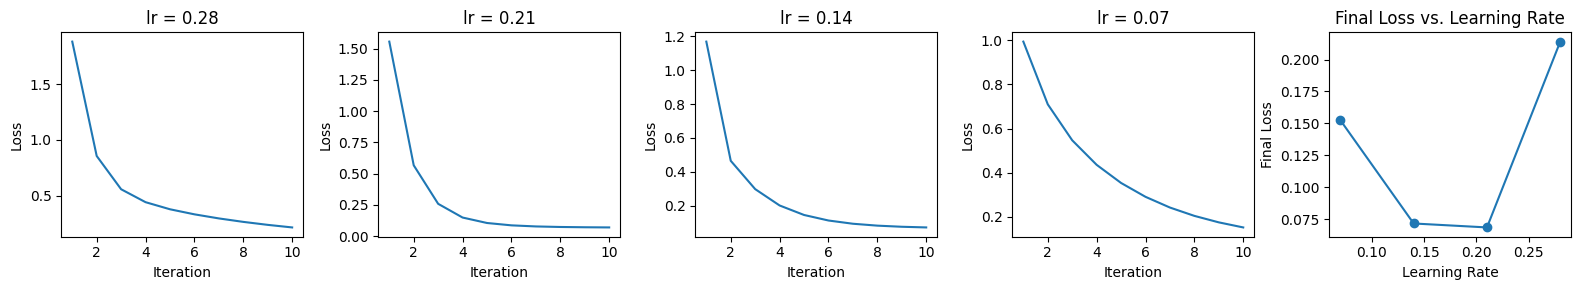

In [47]:
torch.random.manual_seed(41)
lrs = [0.28, 0.21, 0.14, 0.07]
_, axs = plt.subplots(nrows=1, ncols=5, figsize=(16, 3))

print('Number of Axes Available: ', len(axs))
# Should be 5, with the first 4 plotting the 4 learning rates, and the last
# plotting the learning rate v.s. final loss curve.

num_epochs = 10
batch_size = len(trainingData)

# Your code here.
final_losses = []

# Re-initialize the loss function to ensure it's callable
loss = torch.nn.MSELoss()

for i, lr in enumerate(lrs):
    model, losses = train(lr, batch_size, num_epochs)

    # Convergence curve
    # Detach tensors from computation graph and convert to numpy for plotting
    axs[i].plot(range(1, len(losses) + 1), torch.stack(losses).detach().cpu().numpy())
    axs[i].set_title(f'lr = {lr}')
    axs[i].set_xlabel('Iteration')
    axs[i].set_ylabel('Loss')

    # Final loss (detach before appending)
    final_losses.append(losses[-1].detach().item())

# Final loss vs. learning rate
axs[4].plot(lrs, final_losses, marker='o')
axs[4].set_xlabel('Learning Rate')
axs[4].set_ylabel('Final Loss')
axs[4].set_title('Final Loss vs. Learning Rate')

plt.tight_layout()
plt.show()